In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from preprocessing import validate_features, clean_data
import pandas as pd
import numpy as np
df =pd.read_csv("C:\\Users\\saghe\\OneDrive\\Desktop\\GUVI\\Amazon Music Clustering\\Data\\Raw\\single_genre_artists.csv")
df_cleaned = clean_data(df) 
FEATURES = [
        'duration_ms', 'danceability', 'energy',
        'loudness', 'speechiness', 'acousticness', 'instrumentalness',
        'liveness', 'valence', 'tempo'
    ]
features = validate_features(df_cleaned, FEATURES)


Columns before dropping: 23
Columns: ['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit', 'id_artists', 'release_date', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres', 'name_artists', 'popularity_artists']

Columns after dropping: 17
Columns: ['popularity_songs', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'popularity_artists']


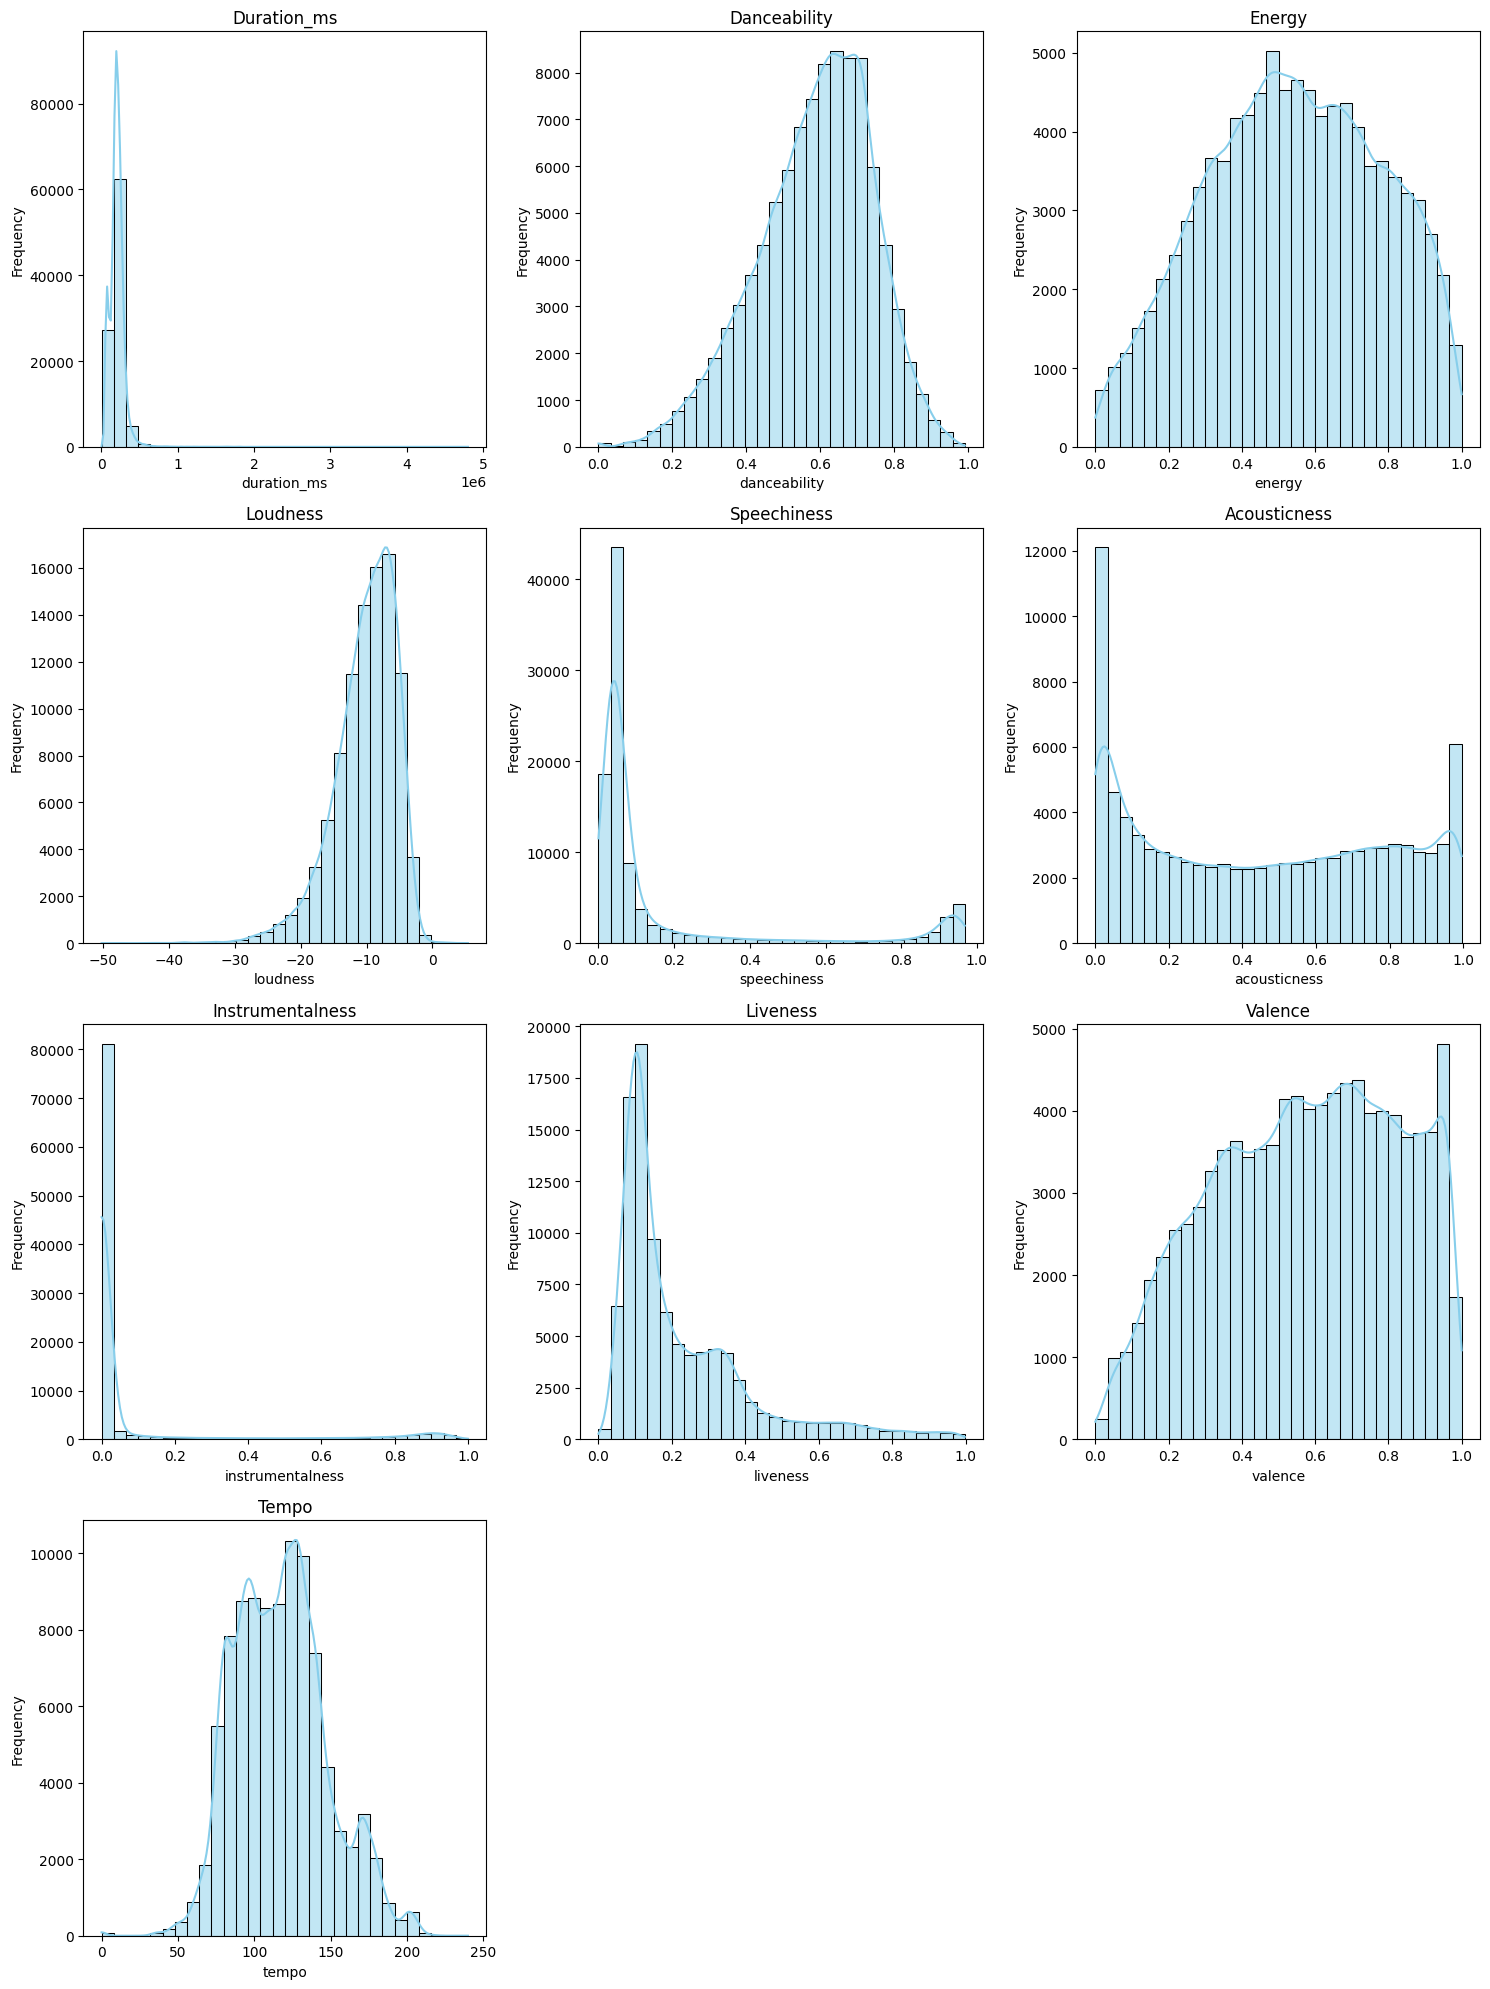

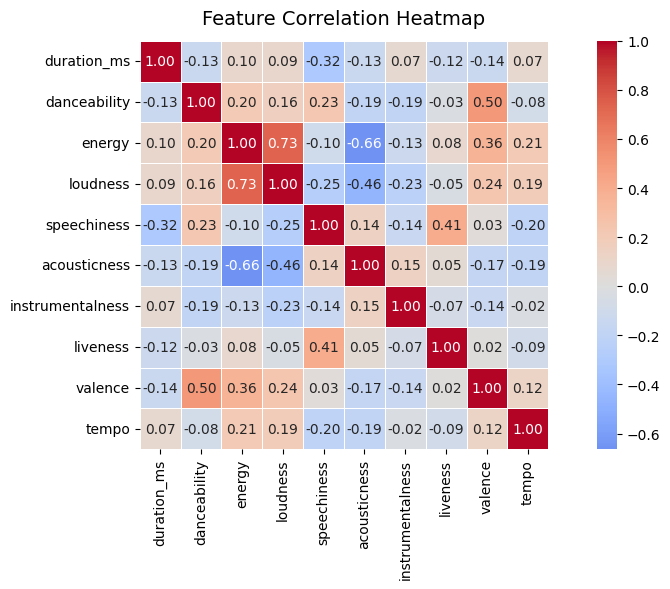

In [3]:
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols
    
plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(features, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30, color='skyblue')
        plt.title(col.capitalize(), fontsize=12)
        plt.xlabel(col)
        plt.ylabel('Frequency')
    
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
correlation_matrix = df[features].corr()
sns.heatmap(
        correlation_matrix, 
        annot=True, 
        cmap='coolwarm', 
        fmt=".2f",
        center=0,
        square=True,
        linewidths=0.5
    )
plt.title("Feature Correlation Heatmap", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [4]:
df_transformed = df.copy()
log_features = ['duration_ms', 'speechiness', 'instrumentalness', 'liveness']
categorical_features = ['key', 'mode', 'time_signature']
    
    # Step 1: Apply log transformation to right-skewed features
print("\n Applying log transformation to skewed features...")
for feature in log_features:
    if feature in df_transformed.columns:
            # Use log1p to handle zeros: log(1 + x)
            # This is safer than log() as it handles 0 values gracefully
        df_transformed[feature] = np.log1p(df_transformed[feature])
        print(f"  Log transformed: {feature}")
    else:
        print(f"  Feature not found: {feature}")
    
print(f"\nFeature transformation completed!")
print(f"   Shape before: {df.shape}, Shape after: {df_transformed.shape}")
    # Step 2: One-hot encode categorical features
print(f"\n One-hot encoding categorical features...")
for feature in categorical_features:
    if feature in df_transformed.columns:
        # Create dummy variables
        dummies = pd.get_dummies(
            df_transformed[feature], 
            prefix=feature, 
            drop_first=False
        )
        # Concatenate with main dataframe
        df_transformed = pd.concat([df_transformed, dummies], axis=1)
        # Drop original column
        df_transformed.drop(columns=[feature], inplace=True)
        print(f"One-hot encoded: {feature} -> {len(dummies.columns)} columns")
    else:
        print(f"Feature not found: {feature}")
    
print(f"\nFeature transformation completed!")
print(f"   Shape before: {df.shape}, Shape after: {df_transformed.shape}")
save_path = "C:\\Users\\saghe\\OneDrive\\Desktop\\GUVI\\Amazon Music Clustering\\Data\\Processed\\transformed_features.csv"
df_transformed.to_csv(save_path, index=False)   
print(f"\nTransformed features saved to: {save_path}")


 Applying log transformation to skewed features...
  Log transformed: duration_ms
  Log transformed: speechiness
  Log transformed: instrumentalness
  Log transformed: liveness

Feature transformation completed!
   Shape before: (95837, 23), Shape after: (95837, 23)

 One-hot encoding categorical features...
One-hot encoded: key -> 12 columns
One-hot encoded: mode -> 2 columns
One-hot encoded: time_signature -> 5 columns

Feature transformation completed!
   Shape before: (95837, 23), Shape after: (95837, 39)

Transformed features saved to: C:\Users\saghe\OneDrive\Desktop\GUVI\Amazon Music Clustering\Data\Processed\transformed_features.csv


In [78]:
df_processed = df.copy()
apply_transformations = True
    # Apply transformations if requested
if apply_transformations:
    df_processed = pd.read_csv("C:\\Users\\saghe\\OneDrive\\Desktop\\GUVI\\Amazon Music Clustering\\Data\\Processed\\transformed_features.csv")
        # Update features list to include one-hot encoded columns
    all_features = df_processed.columns.tolist()
        # Filter to only include features that were originally requested or are one-hot encoded
    features = [f for f in all_features if f in features or 
                   any(f.startswith(cat + '_') for cat in (['key', 'mode', 'time_signature']))]

scaler = StandardScaler()
# Only scale features that exist and are numerical
valid_features = [f for f in features if f in df_processed.columns]
    
    # Filter to only numerical features
numerical_features = [f for f in valid_features 
                          if df_processed[f].dtype in [np.float64, np.int64, np.float32, np.int32, np.float16, np.int16]]
    
if numerical_features:
        scaled_data = scaler.fit_transform(df_processed[numerical_features])
        df_processed[numerical_features] = scaled_data
        
        print("\nScaled Data (first 5 rows):")
        print(df_processed[numerical_features].head())
        print("\nScaled Data Summary:")
        print(df_processed[numerical_features].describe().T)
else:
        print("Warning: No valid numerical features to scale")
        
save_path = "C:\\Users\\saghe\\OneDrive\\Desktop\\GUVI\\Amazon Music Clustering\\Data\\Processed\\scaled_features.csv"
df_processed.to_csv(save_path, index=False)
print(f"\nScaled features saved to: {save_path}")


Scaled Data (first 5 rows):
   duration_ms  danceability    energy  loudness  speechiness  acousticness  \
0    -0.311345     -0.153476 -1.511128 -0.757909    -0.434413      1.616187   
1     0.368718     -1.028518 -1.528056 -1.098629    -0.357753      1.604081   
2     0.221609     -0.488051 -1.418027 -1.127899    -0.395455      1.622240   
3    -0.304798      0.573581 -0.313510 -0.470677     0.093768      1.610134   
4    -0.228190      0.406294 -1.028695 -0.768227    -0.026723      1.610134   

   instrumentalness  liveness   valence     tempo  
0         -0.364976  0.646012  0.321287  0.515005  
1         -0.365068 -0.528010 -0.577455 -1.294487  
2         -0.365068  1.140772 -0.375943 -1.560003  
3         -0.365068  0.037860  0.611464  0.405268  
4         -0.365068  0.905559  1.087031 -1.377593  

Scaled Data Summary:
                    count          mean       std       min       25%  \
duration_ms       95837.0 -9.490016e-18  1.000005 -7.072117 -0.365083   
danceability    


 PCA Explained Variance Ratio: [0.27623951 0.21034352 0.11515658 0.09305091 0.0892068  0.06669042
 0.05611105 0.04455459]
Total Variance Retained: 95.14%


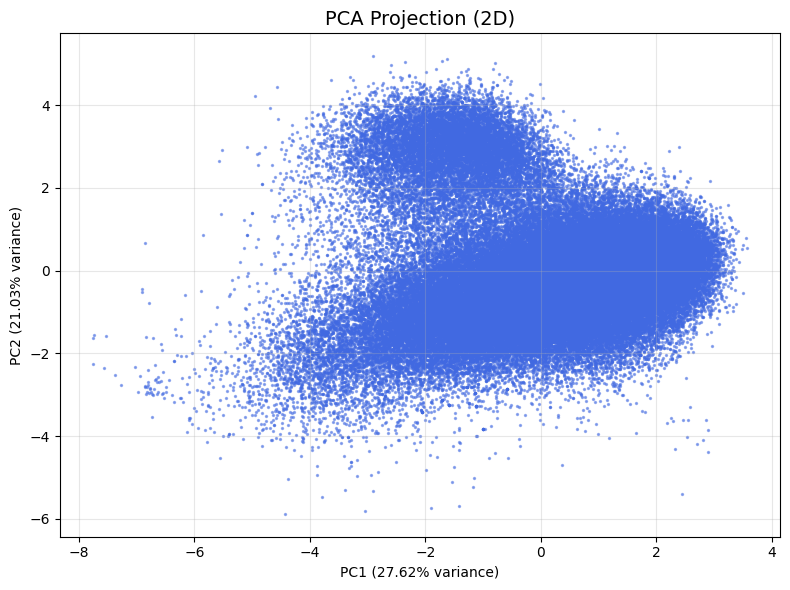

In [79]:
from sklearn.decomposition import PCA
n_components = 8
pca = PCA(n_components=n_components, random_state=42)
pca_result = pca.fit_transform(scaled_data)
df_pca = pd.DataFrame(
        pca_result, 
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
explained_var = pca.explained_variance_ratio_
print(f"\n PCA Explained Variance Ratio: {explained_var}")
print(f"Total Variance Retained: {sum(explained_var)*100:.2f}%")
    
# Visualize PCA
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], s=2, alpha=0.5, color='royalblue')
plt.title("PCA Projection (2D)", fontsize=14)

plt.xlabel(f"PC1 ({explained_var[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.2f}% variance)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_path = "C:\\Users\\saghe\\OneDrive\\Desktop\\GUVI\\Amazon Music Clustering\\Data\\processed\\pca_visualization.png"
plt.savefig(save_path, dpi=300)
plt.show()

In [80]:
df_scaled = pd.DataFrame(
        scaled_data, 
        columns=numerical_features
    )
print("shape of scaled data", df_scaled.shape)
print("\nScaled Result (first 5 rows):")
print(df_scaled.head())
print("shape of scaled data", df_pca.shape)
print("\nPCA Result (first 5 rows):")
print(df_pca.head())

shape of scaled data (95837, 10)

Scaled Result (first 5 rows):
   duration_ms  danceability    energy  loudness  speechiness  acousticness  \
0    -0.311345     -0.153476 -1.511128 -0.757909    -0.434413      1.616187   
1     0.368718     -1.028518 -1.528056 -1.098629    -0.357753      1.604081   
2     0.221609     -0.488051 -1.418027 -1.127899    -0.395455      1.622240   
3    -0.304798      0.573581 -0.313510 -0.470677     0.093768      1.610134   
4    -0.228190      0.406294 -1.028695 -0.768227    -0.026723      1.610134   

   instrumentalness  liveness   valence     tempo  
0         -0.364976  0.646012  0.321287  0.515005  
1         -0.365068 -0.528010 -0.577455 -1.294487  
2         -0.365068  1.140772 -0.375943 -1.560003  
3         -0.365068  0.037860  0.611464  0.405268  
4         -0.365068  0.905559  1.087031 -1.377593  
shape of scaled data (95837, 8)

PCA Result (first 5 rows):
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.691121 -0

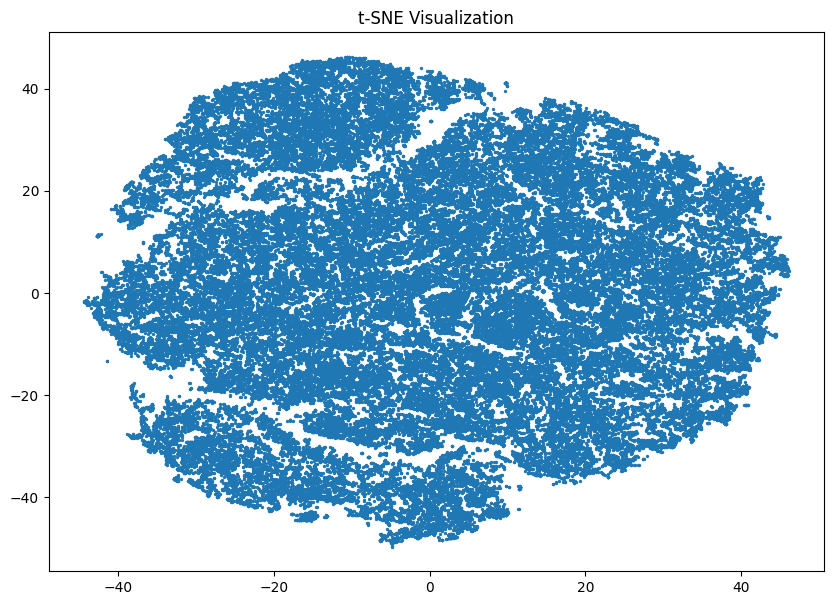

In [81]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
tsne_result = tsne.fit_transform(df_pca)

plt.figure(figsize=(10,7))
plt.scatter(tsne_result[:,0], tsne_result[:,1], s=2)
plt.title("t-SNE Visualization")
save_path = "C:\\Users\\saghe\\OneDrive\\Desktop\\GUVI\\Amazon Music Clustering\\Data\\processed\\tsne_visualization.png"
plt.savefig(save_path, dpi=300)
plt.show()

In [82]:
print(tsne_result.shape)

(95837, 2)


In [83]:
print(tsne_result)

[[-12.291314   13.111359 ]
 [-33.48007    -3.7702935]
 [-34.603565   -5.572157 ]
 ...
 [-29.68722   -37.79677  ]
 [-31.756454  -34.86597  ]
 [-13.270746  -16.92562  ]]


   k=2: Inertia=730082.61, Silhouette=0.2112
   k=3: Inertia=588199.84, Silhouette=0.2499
   k=4: Inertia=541445.48, Silhouette=0.1679
   k=5: Inertia=485181.99, Silhouette=0.1789
   k=6: Inertia=465015.40, Silhouette=0.1899
   k=7: Inertia=455347.92, Silhouette=0.1389
   k=8: Inertia=421685.05, Silhouette=0.1487
   k=9: Inertia=402631.11, Silhouette=0.1512
   k=10: Inertia=386210.82, Silhouette=0.1628
✅ Elbow plot saved to: C:\Users\saghe\OneDrive\Desktop\GUVI\Amazon Music Clustering\Data\processed\elbow_method.png


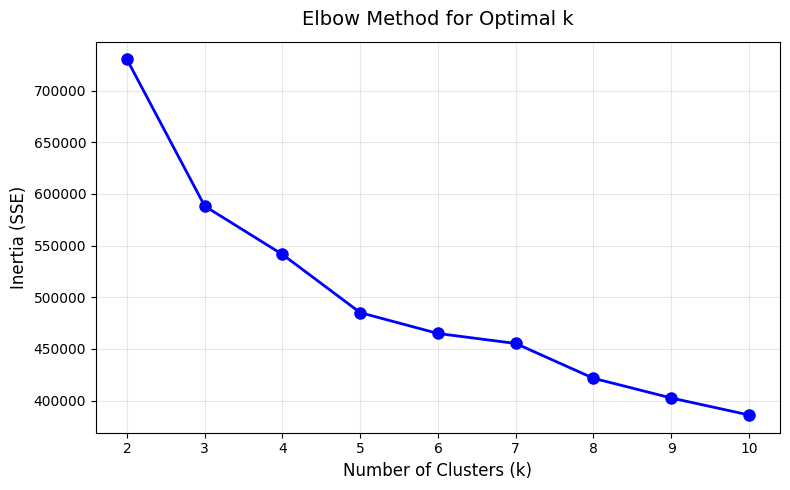

✅ Silhouette plot saved to: C:\Users\saghe\OneDrive\Desktop\GUVI\Amazon Music Clustering\Data\processed\silhouette_scores.png


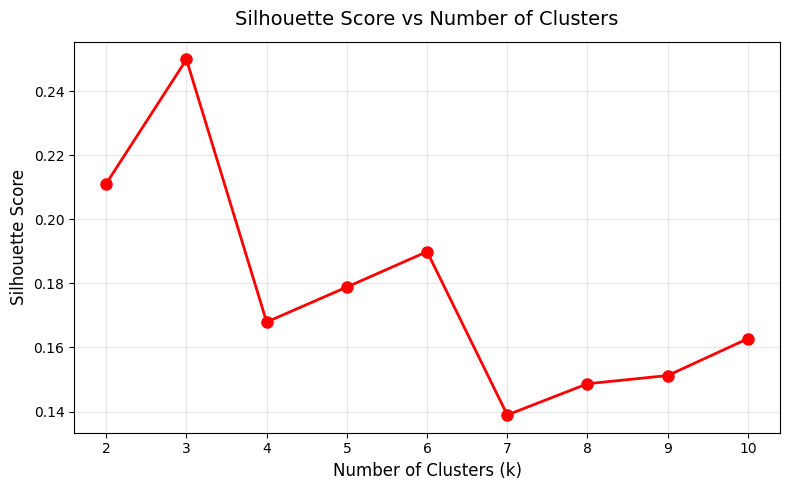


✅ Optimal number of clusters (k): 3
   Silhouette Score: 0.2499


In [85]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

inertia = []
sil_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = MiniBatchKMeans(
        n_clusters=k, 
        random_state=42, 
        batch_size=4096, 
        max_iter=200,
        n_init=10
    )
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(df_pca, kmeans.labels_))
    print(f"   k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_scores[-1]:.4f}")
    
    # Elbow Method Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Inertia (SSE)", fontsize=12)
plt.title("Elbow Method for Optimal k", fontsize=14, pad=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
import os
output_dir = "C:\\Users\\saghe\\OneDrive\\Desktop\\GUVI\\Amazon Music Clustering\\Data\\processed"
elbow_path = os.path.join(output_dir, "elbow_method.png")
plt.savefig(elbow_path, dpi=300, bbox_inches='tight')
print(f"✅ Elbow plot saved to: {elbow_path}")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score vs Number of Clusters", fontsize=14, pad=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
   
sil_path = os.path.join(output_dir, "silhouette_scores.png")
plt.savefig(sil_path, dpi=300, bbox_inches='tight')
print(f"✅ Silhouette plot saved to: {sil_path}")
    
plt.show()

best_k_idx = np.argmax(sil_scores)
best_k = list(k_range)[best_k_idx]
print(f"\n✅ Optimal number of clusters (k): {best_k}")
print(f"   Silhouette Score: {sil_scores[best_k_idx]:.4f}")

[[-1.67050134  0.48877163 -0.31990858 -0.65956133  2.30771518  0.37716912
  -0.35019052  1.08955891  0.04210705 -0.54996444]
 [ 0.22271636 -0.62394292 -0.88835591 -0.56480754 -0.40323851  0.77699611
   0.33652352 -0.2120283  -0.655251   -0.17747125]
 [ 0.29284586  0.29288327  0.68025363  0.55312478 -0.33264448 -0.6213354
  -0.13579482 -0.14516441  0.43016238  0.26881917]]
✅ K-Means clustering completed.
   Cluster distribution:
Cluster_KMeans
0    13013
1    32209
2    50615
Name: count, dtype: int64


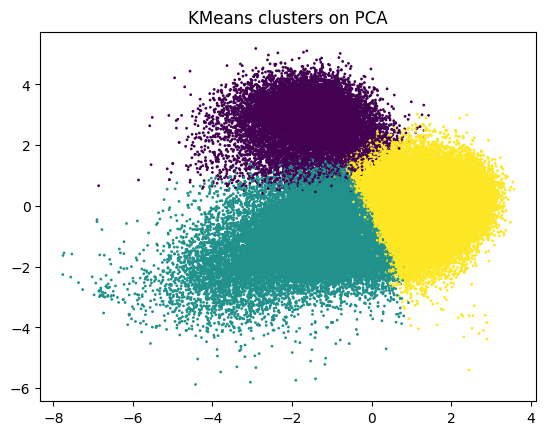

In [139]:
n_clusters = 3
kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=42,
        batch_size=4096,
        max_iter=300,
        n_init=10
    )
    
df_scaled = df_scaled.copy()
df_scaled['Cluster_KMeans'] = kmeans.fit_predict(df_scaled)
centroids = kmeans.cluster_centers_
print(centroids)
print(f"✅ K-Means clustering completed.")
print(f"   Cluster distribution:\n{df_scaled['Cluster_KMeans'].value_counts().sort_index()}")
plt.scatter(df_pca["PC1"], df_pca["PC2"], c=df_pca["Cluster_KMeans"], s=1)
plt.title("KMeans clusters on PCA")
plt.show()

In [90]:
df_tsne = pd.DataFrame(tsne_result,columns=['TSNE1','TSNE2'])
df_tsne['Cluster_KMeans'] = kmeans.fit_predict(df_tsne)
print(df_tsne.head())
print(df_tsne['Cluster_KMeans'].unique())

       TSNE1      TSNE2  Cluster_KMeans
0 -12.291314  13.111359               0
1 -33.480068  -3.770293               0
2 -34.603565  -5.572157               1
3 -13.775013  15.946550               0
4  -9.380414  14.886856               0
[0 1 2]


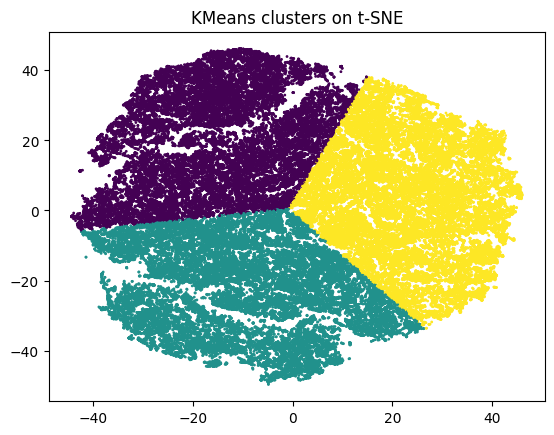

In [93]:
plt.scatter(df_tsne['TSNE1'], df_tsne['TSNE2'], c=df_tsne["Cluster_KMeans"], s=1)
plt.title("KMeans clusters on t-SNE")
plt.show()

In [18]:
print(pca.explained_variance_ratio_)

[0.27623951 0.21034352 0.11515658 0.09305091 0.0892068  0.06669042
 0.05611105 0.04455459]


In [19]:
print(df_pca.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.691121 -0.034858 -0.474162  0.481548 -1.198009  1.292358  0.015495   
1 -2.438224 -1.099838 -0.536363 -1.220268 -0.280696  0.700290 -0.290883   
2 -2.478403 -0.133858  0.085801 -1.087443  0.137883  1.656492  0.287551   
3 -0.783853  0.576412 -0.925241  0.416866 -0.840591  0.882399 -0.244383   
4 -1.631997  1.048750 -0.923032 -0.525613  0.177439  1.859006  0.015310   

        PC8  Cluster_KMeans  
0  0.022568               0  
1 -0.382096               0  
2 -0.251273               0  
3  0.459025               0  
4 -0.330581               0  


In [140]:
from sklearn.cluster import DBSCAN
# DBSCAN
df_scaled = df_scaled.copy()
dbscan = DBSCAN(eps=2.4, min_samples=10, n_jobs=1)
df_scaled['Cluster_DBSCAN'] = dbscan.fit_predict(df_scaled)

# Print result
labels = dbscan.labels_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Clusters: {n_clusters}")
print(f"Noise: {n_noise}")


Clusters: 1
Noise: 129


In [100]:
df_pca['Cluster_DBSCAN1'] = dbscan.fit_predict(df_scaled)

In [104]:
print(labels)
print(len(labels))

[0 0 0 ... 0 0 0]
95837


In [107]:
df_pca["Cluster_DBSCAN1"].unique()

array([ 0, -1])

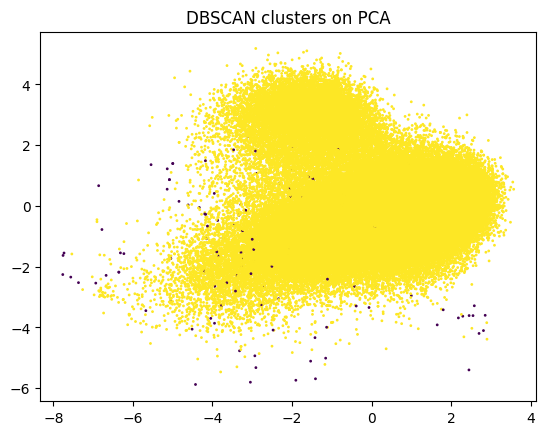

In [ ]:
plt.scatter(df_pca["PC1"], df_pca["PC2"], c=df_pca["Cluster_DBSCAN1"], s=1)
plt.title("DBSCAN clusters on PCA")
plt.show()

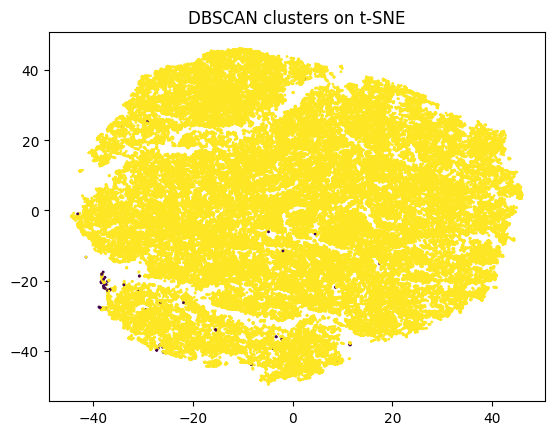

In [110]:
plt.scatter(df_tsne["TSNE1"], df_tsne["TSNE2"], c=df_pca["Cluster_DBSCAN1"], s=1)
plt.title("DBSCAN clusters on t-SNE")
plt.show()

In [112]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


🔹 Generating Hierarchical Clustering...
   Using sample of 20000 for dendrogram visualization...
✅ Dendrogram saved to: C:\Users\saghe\OneDrive\Desktop\GUVI\Amazon Music Clustering\Data\processed\dendrogram.png


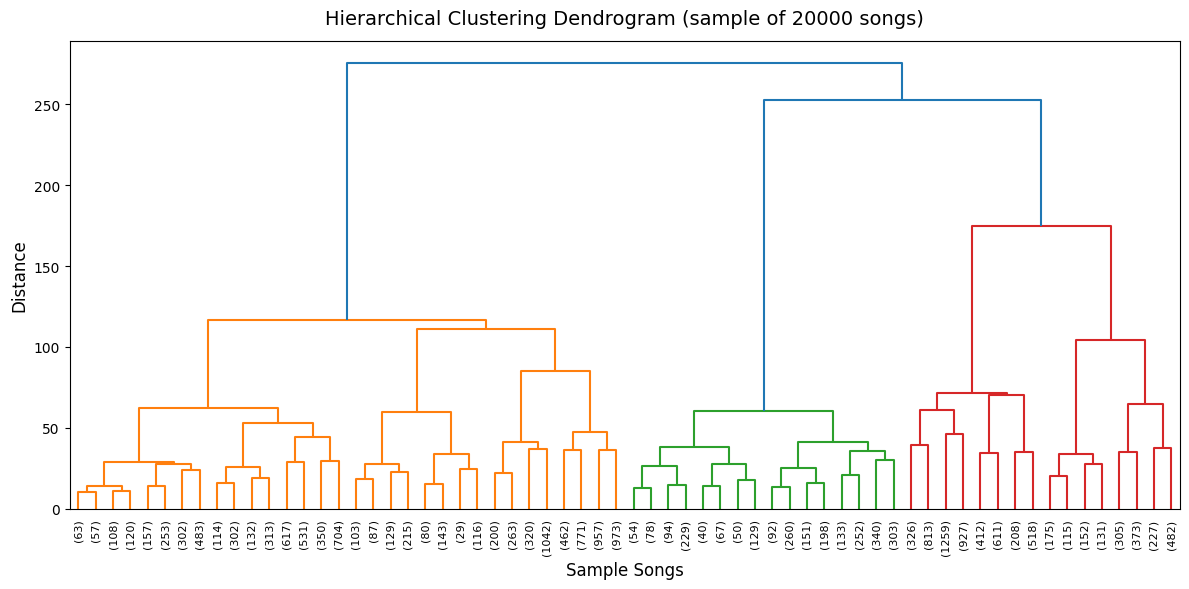

   Applying Agglomerative Clustering with 3 clusters...
✅ Hierarchical clustering completed.


In [164]:
print(f"\n🔹 Generating Hierarchical Clustering...")
sample_size = 20000
save_plot = True
# Create dendrogram on sample
if len(df_scaled) > sample_size:
    print(f"   Using sample of {sample_size} for dendrogram visualization...")
    subset = df_pca.sample(sample_size, random_state=42)
else:
    subset = df_pca.copy()
    
Z = linkage(subset, method='ward')
    
plt.figure(figsize=(12, 6))
dendrogram(
    Z, 
    truncate_mode='level', 
    p=5,
    leaf_rotation=90,
    leaf_font_size=8
    )
plt.title(f"Hierarchical Clustering Dendrogram (sample of {len(subset)} songs)", 
              fontsize=14, pad=12)
plt.xlabel("Sample Songs", fontsize=12)
plt.ylabel("Distance", fontsize=12)
plt.tight_layout()
    
if save_plot:
    dendro_path = os.path.join(output_dir, "dendrogram.png")
    plt.savefig(dendro_path, dpi=300, bbox_inches='tight')
    print(f"✅ Dendrogram saved to: {dendro_path}")
    
plt.show()
    
 # Apply clustering to full dataset if n_clusters is specified
df_pca = df_pca.copy()
n_clusters = 3
if n_clusters is not None:
    print(f"   Applying Agglomerative Clustering with {n_clusters} clusters...")
    hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
    subset['Cluster_Hierarchical'] = hierarchical.fit_predict(subset)
    print(f"✅ Hierarchical clustering completed.")
else:
    hierarchical = None
    print("ℹ️ Dendrogram created. Set n_clusters to apply clustering to full dataset.")
    

In [165]:
subset

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,Cluster_KMeans,Cluster_DBSCAN,Cluster_DBSCAN1,Cluster_Hierarchical
43044,-1.018700,-0.858594,-0.189907,-0.688538,-0.518366,0.611664,-1.701891,-0.151741,1,0,0,0
55472,0.150455,0.749751,-2.013357,-0.074085,-0.022098,-0.776387,1.373444,-1.118665,2,0,0,1
95364,1.535285,0.229196,-0.480638,-0.830120,0.582598,0.140341,0.305906,-0.261740,2,0,0,1
87709,-0.164889,2.728048,2.119097,0.222515,0.370711,1.096213,-0.693191,0.880672,0,0,0,2
93645,2.522867,-1.000346,2.285234,1.133337,-1.068264,-0.279392,0.069713,-0.119824,2,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
22935,-1.194768,3.258975,0.562401,0.639686,-0.322379,-0.049210,-0.176272,0.409669,0,0,0,2
40446,-0.577409,2.860207,1.235776,0.465916,-0.095123,-0.611377,-0.854124,0.496018,0,0,0,2
15725,-0.498334,3.531906,2.276092,1.425920,-0.640362,-0.100233,0.036822,0.936821,0,0,0,2
14504,-0.789598,-0.531426,-1.247668,-1.176655,-0.104649,0.184123,-0.264321,1.134017,1,0,0,0


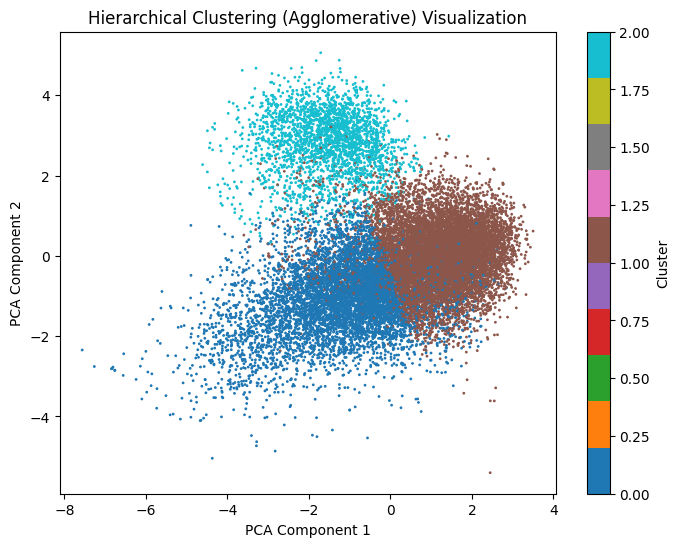

In [169]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    subset["PC1"],
    subset["PC2"],
    c=subset['Cluster_Hierarchical'],
    cmap='tab10',
    s=1
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Hierarchical Clustering (Agglomerative) Visualization")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [129]:
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,Cluster_KMeans,Cluster_DBSCAN,Cluster_DBSCAN1
0,-1.691121,-0.034858,-0.474162,0.481548,-1.198009,1.292358,0.015495,0.022568,1,0,0
1,-2.438224,-1.099838,-0.536363,-1.220268,-0.280696,0.700290,-0.290883,-0.382096,1,0,0
2,-2.478403,-0.133858,0.085801,-1.087443,0.137883,1.656492,0.287551,-0.251273,1,0,0
3,-0.783853,0.576412,-0.925241,0.416866,-0.840591,0.882399,-0.244383,0.459025,1,0,0
4,-1.631997,1.048750,-0.923032,-0.525613,0.177439,1.859006,0.015310,-0.330581,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
95832,1.607710,-0.081693,-0.156814,0.713325,-0.980120,-0.570198,0.160510,0.167222,2,0,0
95833,1.497789,-1.263549,0.751675,-0.744179,-0.231286,-0.801721,-0.323184,0.534327,2,0,0
95834,-4.624584,0.013853,-2.873639,2.201177,2.465301,-0.014813,0.207336,-1.621377,1,0,0
95835,-4.539662,-1.557260,-1.742969,1.030654,2.652636,-0.211557,0.741679,-0.214622,1,0,0


In [143]:
df_scaled

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster_KMeans,Cluster_DBSCAN
0,-0.311345,-0.153476,-1.511128,-0.757909,-0.434413,1.616187,-0.364976,0.646012,0.321287,0.515005,1,0
1,0.368718,-1.028518,-1.528056,-1.098629,-0.357753,1.604081,-0.365068,-0.528010,-0.577455,-1.294487,1,0
2,0.221609,-0.488051,-1.418027,-1.127899,-0.395455,1.622240,-0.365068,1.140772,-0.375943,-1.560003,1,0
3,-0.304798,0.573581,-0.313510,-0.470677,0.093768,1.610134,-0.365068,0.037860,0.611464,0.405268,1,0
4,-0.228190,0.406294,-1.028695,-0.768227,-0.026723,1.610134,-0.365068,0.905559,1.087031,-1.377593,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
95832,-0.144850,0.560713,0.113908,0.800599,-0.485504,-1.038056,-0.365068,-0.292610,0.264864,1.608703,2,0
95833,0.732240,-0.378671,0.558254,1.372746,-0.532123,-0.956340,-0.365068,-0.718639,-1.117507,0.414907,2,0
95834,-1.715551,0.142494,-2.217003,-3.877872,-0.117834,1.625267,3.633127,-0.658490,1.272422,-1.620420,1,0
95835,-0.023385,-0.159910,-2.149717,-3.241498,-0.187243,1.625267,3.597233,-0.638768,-0.758816,-1.783486,1,0


In [115]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [177]:
df = df_scaled.copy()
cluster_column = 'Cluster_KMeans' 
features = ["duration_ms", "danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]
print(f"\n🔹 Evaluating {cluster_column} clustering quality...")
# Filter features to only those that exist in the dataframe
valid_features = [f for f in features if f in df.columns]
if not valid_features:
    raise ValueError(f"No valid features found. Available columns: {df.columns.tolist()}")
    
if len(valid_features) < len(features):
    missing = set(features) - set(valid_features)
    print(f"⚠️ Warning: Some features not found: {missing}")
    
# Extract feature matrix and labels
X = df[valid_features].values
labels = df[cluster_column].values
    
# Check for valid clusters
unique_labels = np.unique(labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    
if n_clusters < 2:
    print("⚠️ Warning: Less than 2 clusters found. Metrics may be unreliable.")
    print({'silhouette_score': 0.0,
            'davies_bouldin_index': float('inf'),
            'n_clusters': n_clusters
        }
    )
# Compute metrics
silhouette = silhouette_score(X, labels)
db_index = davies_bouldin_score(X, labels)
    
metrics = {
        'silhouette_score': silhouette,
        'davies_bouldin_index': db_index,
        'n_clusters': n_clusters
    }
    
print(f"✅ Silhouette Score: {silhouette:.4f}")
print(f"   (Higher is better, range: -1 to 1)")
print(f"✅ Davies-Bouldin Index: {db_index:.4f}")
print(f"   (Lower is better)")
print(f"✅ Number of clusters: {n_clusters}")


🔹 Evaluating Cluster_KMeans clustering quality...
✅ Silhouette Score: 0.2390
   (Higher is better, range: -1 to 1)
✅ Davies-Bouldin Index: 1.5637
   (Lower is better)
✅ Number of clusters: 3


In [178]:
cluster_summary = df.groupby(cluster_column)[features].mean()
print("\nCluster Summary (Mean Feature Values):")
print(cluster_summary.round(3))


Cluster Summary (Mean Feature Values):
                duration_ms  danceability  energy  loudness  speechiness  \
Cluster_KMeans                                                             
0                    -1.681         0.492  -0.322    -0.659        2.300   
1                     0.210        -0.637  -0.928    -0.598       -0.403   
2                     0.298         0.279   0.673     0.550       -0.335   

                acousticness  instrumentalness  liveness  valence  tempo  
Cluster_KMeans                                                            
0                      0.376            -0.350     1.087    0.046 -0.547  
1                      0.833             0.353    -0.224   -0.645 -0.176  
2                     -0.627            -0.135    -0.137    0.399  0.253  


✅ Cluster profile heatmap saved to: C:\Users\saghe\OneDrive\Desktop\GUVI\Amazon Music Clustering\Data\processed\cluster_profile_heatmap.png


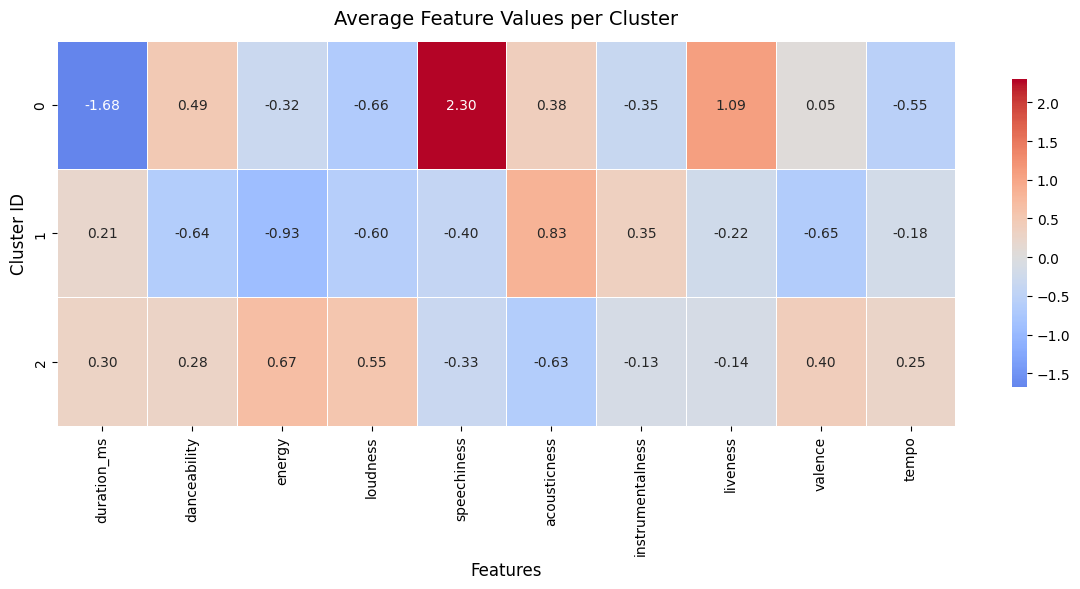

In [179]:
plt.figure(figsize=(12, 6))
sns.heatmap(
        cluster_summary, 
        annot=True, 
        cmap="coolwarm", 
        fmt=".2f",
        center=0,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
plt.title("Average Feature Values per Cluster", fontsize=14, pad=12)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Cluster ID", fontsize=12)
plt.tight_layout()

save_path = "C:\\Users\\saghe\\OneDrive\\Desktop\\GUVI\\Amazon Music Clustering\\Data\\processed\\cluster_profile_heatmap.png"
if save_path:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Cluster profile heatmap saved to: {save_path}")
    
plt.show()

✅ Cluster size distribution saved to: C:\Users\saghe\OneDrive\Desktop\GUVI\Amazon Music Clustering\Data\processed\cluster_size_distribution.png


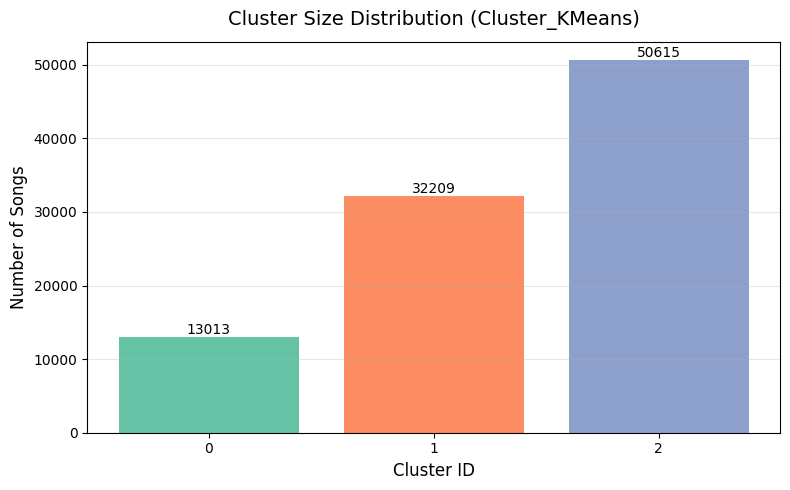

In [180]:
plt.figure(figsize=(8, 5))
cluster_counts = df[cluster_column].value_counts().sort_index()
    
bars = plt.bar(cluster_counts.index.astype(str), cluster_counts.values, 
                   color=plt.cm.Set2(range(len(cluster_counts))))
    
    # Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10)
    
plt.title(f"Cluster Size Distribution ({cluster_column})", fontsize=14, pad=12)
plt.xlabel("Cluster ID", fontsize=12)
plt.ylabel("Number of Songs", fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

save_path = "C:\\Users\\saghe\\OneDrive\\Desktop\\GUVI\\Amazon Music Clustering\\Data\\processed\\cluster_size_distribution.png"
if save_path:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Cluster size distribution saved to: {save_path}")
    
plt.show()

In [185]:
cluster_summary

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster_KMeans,,,,,,,,,,
0,-1.680976,0.492107,-0.321565,-0.659222,2.300306,0.375958,-0.350489,1.086537,0.046272,-0.546987
1,0.210387,-0.636675,-0.928084,-0.597654,-0.403479,0.832926,0.352970,-0.223932,-0.645166,-0.176400
2,0.298294,0.278631,0.673262,0.549803,-0.334648,-0.626693,-0.134503,-0.136847,0.398657,0.252882


In [184]:
interpretations = {}
    
for cluster_id, row in cluster_summary.iterrows():
        # Calculate mean across all features for this cluster
        cluster_mean = row.mean()
        
        # Features above cluster mean
        high_features = row[row > cluster_mean].index.tolist()
        # Features below cluster mean
        low_features = row[row < cluster_mean].index.tolist()
        
        # Generate interpretation
        interpretation = []
        if 'energy' in high_features and 'danceability' in high_features:
            interpretation.append("Upbeat / Party tracks")
        if 'acousticness' in high_features:
            interpretation.append("Chill or Acoustic songs")
        if 'instrumentalness' in high_features:
            interpretation.append("Instrumental / Ambient tracks")
        if 'valence' in high_features:
            interpretation.append("Positive mood")
        if 'speechiness' in high_features:
            interpretation.append("Speech-heavy / Rap")
        if not interpretation:
            interpretation.append("Mixed characteristics")
        
        interpretations[cluster_id] = {
            'high_features': high_features,
            'low_features': low_features,
            'interpretation': interpretation
        }

Cluster 0 mean: 0.07419414975045452
duration_ms        -1.680976
danceability        0.492107
energy             -0.321565
loudness           -0.659222
speechiness         2.300306
acousticness        0.375958
instrumentalness   -0.350489
liveness            1.086537
valence             0.046272
tempo              -0.546987
Name: 0, dtype: float64
 High features: ['danceability', 'speechiness', 'acousticness', 'liveness']
 Low features: ['duration_ms', 'energy', 'loudness', 'instrumentalness', 'valence', 'tempo']
Cluster 1 mean: -0.2215107670545627
duration_ms         0.210387
danceability       -0.636675
energy             -0.928084
loudness           -0.597654
speechiness        -0.403479
acousticness        0.832926
instrumentalness    0.352970
liveness           -0.223932
valence            -0.645166
tempo              -0.176400
Name: 1, dtype: float64
 High features: ['duration_ms', 'acousticness', 'instrumentalness', 'tempo']
 Low features: ['danceability', 'energy', 'loudness', 

In [187]:
cluster_mean = 0.07419414975045452
high_features = row[row > cluster_mean].index.tolist()
print(high_features)

['duration_ms', 'danceability', 'energy', 'loudness', 'valence', 'tempo']


In [190]:
interpretations

{0: {'high_features': ['danceability',
   'speechiness',
   'acousticness',
   'liveness'],
  'low_features': ['duration_ms',
   'energy',
   'loudness',
   'instrumentalness',
   'valence',
   'tempo'],
  'interpretation': ['Chill or Acoustic songs', 'Speech-heavy / Rap']},
 1: {'high_features': ['duration_ms',
   'acousticness',
   'instrumentalness',
   'tempo'],
  'low_features': ['danceability',
   'energy',
   'loudness',
   'speechiness',
   'liveness',
   'valence'],
  'interpretation': ['Chill or Acoustic songs',
   'Instrumental / Ambient tracks']},
 2: {'high_features': ['duration_ms',
   'danceability',
   'energy',
   'loudness',
   'valence',
   'tempo'],
  'low_features': ['speechiness',
   'acousticness',
   'instrumentalness',
   'liveness'],
  'interpretation': ['Upbeat / Party tracks', 'Positive mood']}}

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
     -------------------------------- ------- 2.1/2.6 MB 21.1 MB/s eta 0:00:01
     ---------------------------------------- 2.6/2.6 MB 17.7 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395230 sha256=e79c8fbfba007b860dc0d9c2971ccdd7a494ea2b2a640ad1fd1442fc56aa1a41
  Stored in directory: c:\users\saghe\appdata\local\pip\cache\wheels\82\ff\9c\fb3aedfa7966808cbd411ebca7df35bf731fe9e01c2cd699ee
Successfully built p

In [175]:
print("\n🎵 Cluster Interpretation:")
print("=" * 50)
    
for cluster_id in sorted(interpretations.keys()):
        info = interpretations[cluster_id]
        print(f"\n🎧 Cluster {cluster_id}:")
        print(f"   🔺 High in: {', '.join(info['high_features'][:5])}")
        if len(info['high_features']) > 5:
            print(f"      ... and {len(info['high_features']) - 5} more")
        print(f"   🔻 Low in: {', '.join(info['low_features'][:5])}")
        if len(info['low_features']) > 5:
            print(f"      ... and {len(info['low_features']) - 5} more")
        print(f"   💡 Possible interpretation: {', '.join(info['interpretation'])}")


🎵 Cluster Interpretation:

🎧 Cluster 0:
   🔺 High in: PC3, PC4, PC5, PC6, PC7
      ... and 1 more
   🔻 Low in: PC1, PC2
   💡 Possible interpretation: Mixed characteristics

🎧 Cluster 1:
   🔺 High in: PC1
   🔻 Low in: PC2, PC3, PC4, PC5, PC6
      ... and 2 more
   💡 Possible interpretation: Mixed characteristics

🎧 Cluster 2:
   🔺 High in: PC2, PC3
   🔻 Low in: PC1, PC4, PC5, PC6, PC7
      ... and 1 more
   💡 Possible interpretation: Mixed characteristics


In [191]:
df_scaled

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster_KMeans,Cluster_DBSCAN
0,-0.311345,-0.153476,-1.511128,-0.757909,-0.434413,1.616187,-0.364976,0.646012,0.321287,0.515005,1,0
1,0.368718,-1.028518,-1.528056,-1.098629,-0.357753,1.604081,-0.365068,-0.528010,-0.577455,-1.294487,1,0
2,0.221609,-0.488051,-1.418027,-1.127899,-0.395455,1.622240,-0.365068,1.140772,-0.375943,-1.560003,1,0
3,-0.304798,0.573581,-0.313510,-0.470677,0.093768,1.610134,-0.365068,0.037860,0.611464,0.405268,1,0
4,-0.228190,0.406294,-1.028695,-0.768227,-0.026723,1.610134,-0.365068,0.905559,1.087031,-1.377593,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
95832,-0.144850,0.560713,0.113908,0.800599,-0.485504,-1.038056,-0.365068,-0.292610,0.264864,1.608703,2,0
95833,0.732240,-0.378671,0.558254,1.372746,-0.532123,-0.956340,-0.365068,-0.718639,-1.117507,0.414907,2,0
95834,-1.715551,0.142494,-2.217003,-3.877872,-0.117834,1.625267,3.633127,-0.658490,1.272422,-1.620420,1,0
95835,-0.023385,-0.159910,-2.149717,-3.241498,-0.187243,1.625267,3.597233,-0.638768,-0.758816,-1.783486,1,0


In [195]:
original_data_path = "C:/Users/saghe/OneDrive/Desktop/GUVI/Amazon Music Clustering/Data/Raw/single_genre_artists.csv"


In [197]:
if not os.path.exists(original_data_path):
        raise FileNotFoundError(f"Original data file not found: {original_data_path}")
   
original_df = pd.read_csv(original_data_path)
clustered_df = df_scaled.copy()
cluster_columns = ["Cluster_KMeans"]
print(f"✅ Original data shape: {original_df.shape}")
print(f"✅ Clustered data shape: {clustered_df.shape}")
    
    # Validate shapes match
if len(original_df) != len(clustered_df):
    raise ValueError(
        f"Data shape mismatch: original={len(original_df)}, "
        f"clustered={len(clustered_df)}"
    )
    
# Merge cluster labels
final_df = original_df.copy()
    
if cluster_columns is None:
    # Auto-detect cluster columns
    cluster_columns = [col for col in clustered_df.columns 
                          if col.startswith('Cluster_')]
    
for col in cluster_columns:
    if col in clustered_df.columns:
        final_df[col] = clustered_df[col].values
        print(f"   ✅ Added {col} to final dataset")
    else:
         print(f"   ⚠️ Warning: {col} not found in clustered data")
    

✅ Original data shape: (95837, 23)
✅ Clustered data shape: (95837, 12)
   ✅ Added Cluster_KMeans to final dataset


In [238]:
final_df
final_df.to_csv("C:/Users/saghe/OneDrive/Desktop/GUVI/Amazon Music Clustering/Data/Processed/final_clustered_data.csv", index=False)
print(f"\nFinal clustered data saved")


Final clustered data saved


In [222]:
popularity_column: str = "popularity_songs"
top_n: int = 5
track_name_col: str = "name_song"
artist_name_col: str = "name_artists"


In [223]:
df = final_df.copy()

id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
Cluster_KMeans        0
dtype: int64

In [224]:
print(f"\n🔹 Extracting Top {top_n} songs per {cluster_column}...")
    
# Check if required columns exist
required_cols = [cluster_column, popularity_column, track_name_col, artist_name_col]
missing_cols = [col for col in required_cols if col not in df.columns]
    
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Group by cluster and get top N tracks
top_tracks = (
    df.groupby(cluster_column)
    .apply(
        lambda x: x.nlargest(top_n, popularity_column)[
            [track_name_col, artist_name_col, popularity_column, cluster_column]
        ]
    )
    .reset_index(drop=True)
)

# Sort by cluster and popularity
top_tracks = top_tracks.sort_values([cluster_column, popularity_column], 
                                    ascending=[True, False])

print(f"\nTop Tracks Summary:")
for cluster_id in sorted(top_tracks[cluster_column].unique()):
    cluster_tracks = top_tracks[top_tracks[cluster_column] == cluster_id]
    print(f"\n  Cluster {cluster_id}:")
    for idx, row in cluster_tracks.iterrows():
        print(f"    - {row[track_name_col]} by {row[artist_name_col]} "
                f"(Popularity: {row[popularity_column]})")



🔹 Extracting Top 5 songs per Cluster_KMeans...

Top Tracks Summary:

  Cluster 0:
    - Miss YOU! by CORPSE (Popularity: 76)
    - Beautiful Pain (Losin My Mind) by Polo G (Popularity: 72)
    - Never Satisfied by CORPSE (Popularity: 72)
    - Siempre Fine by Ak4:20 (Popularity: 72)
    - Gentleman by SL (Popularity: 70)

  Cluster 1:
    - Arcade by Duncan Laurence (Popularity: 89)
    - Put Your Records On by Ritt Momney (Popularity: 87)
    - Hold On by Chord Overstreet (Popularity: 83)
    - Arcade by Duncan Laurence (Popularity: 83)
    - ROLLIN N CONTROLLIN FREESTYLE by DUSTY LOCANE (Popularity: 83)

  Cluster 2:
    - Astronaut In The Ocean by Masked Wolf (Popularity: 98)
    - WITHOUT YOU by The Kid LAROI (Popularity: 94)
    - Hecha Pa' Mi by Boza (Popularity: 92)
    - What You Know Bout Love by Pop Smoke (Popularity: 91)
    - 911 by Sech (Popularity: 91)


C:\Users\saghe\AppData\Local\Temp\ipykernel_33260\3282576077.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [230]:
print("\n🔹 Generating summary report...")

# Filter features to only those in cluster_summary
valid_features = [f for f in features if f in cluster_summary.columns]

report_lines = []
report_lines.append("Amazon Music Clustering — Final Summary Report\n")
report_lines.append("=" * 60 + "\n\n")
report_lines.append(f"Total songs analyzed: {len(df):,}\n")
report_lines.append(f"Number of {cluster_column} clusters: "
                    f"{df[cluster_column].nunique()}\n")
report_lines.append("=" * 60 + "\n\n")

# Cluster size distribution
cluster_sizes = df[cluster_column].value_counts().sort_index()
report_lines.append("Cluster Size Distribution:\n")
for cluster_id, size in cluster_sizes.items():
    percentage = (size / len(df)) * 100
    report_lines.append(f"   Cluster {cluster_id}: {size:,} songs ({percentage:.2f}%)\n")
report_lines.append("\n")

# Detailed cluster analysis
report_lines.append("Detailed Cluster Analysis:\n")
report_lines.append("-" * 60 + "\n")

for cluster_id, row in cluster_summary.iterrows():
    report_lines.append(f"\nCluster {cluster_id} Summary:\n")
    report_lines.append(f"   Size: {cluster_sizes[cluster_id]:,} songs\n")
    
    # High and low features (only from valid features)
    cluster_mean = row.mean()
    high_feats = [f for f in row[row > cluster_mean].index.tolist() if f in valid_features]
    low_feats = [f for f in row[row < cluster_mean].index.tolist() if f in valid_features]
    
    report_lines.append(f"   High in: {', '.join(high_feats[:8])}\n")
    if len(high_feats) > 8:
        report_lines.append(f"      ... and {len(high_feats) - 8} more features\n")
    
    report_lines.append(f"   Low in: {', '.join(low_feats[:8])}\n")
    if len(low_feats) > 8:
        report_lines.append(f"      ... and {len(low_feats) - 8} more features\n")
    
    # Interpretation
    interpretation = []
    if 'energy' in high_feats and 'danceability' in high_feats:
        interpretation.append("Upbeat / Party tracks")
    if 'acousticness' in high_feats:
        interpretation.append("Chill or Acoustic songs")
    if 'instrumentalness' in high_feats:
        interpretation.append("Instrumental / Ambient tracks")
    if 'valence' in high_feats:
        interpretation.append("Positive mood")
    if 'speechiness' in high_feats:
        interpretation.append("Speech-heavy / Rap")
    if 'liveness' in high_feats:
        interpretation.append("Live performance")
    if not interpretation:
        interpretation.append("Mixed characteristics")
    
    report_lines.append(f"   Possible interpretation: {', '.join(interpretation)}\n")
    
    # Key feature values
    report_lines.append(f"   Key Feature Values:\n")
    key_features = ['danceability', 'energy', 'valence', 'tempo']
    for feat in key_features:
        if feat in row.index:
            report_lines.append(f"      {feat}: {row[feat]:.3f}\n")

report_lines.append("\n" + "=" * 60 + "\n")
report_lines.append("Report generated successfully.\n")

report_text = "".join(report_lines)
save_path = "C:/Users/saghe/OneDrive/Desktop/GUVI/Amazon Music Clustering/Data/processed/summary_report.txt"
with open(save_path, 'w') as f:
    f.write(report_text)    
print(f" Summary report saved to: {save_path}")   


🔹 Generating summary report...
 Summary report saved to: C:/Users/saghe/OneDrive/Desktop/GUVI/Amazon Music Clustering/Data/processed/summary_report.txt


In [226]:
report_text

'🎵 Amazon Music Clustering — Final Summary Report\n============================================================\n\nTotal songs analyzed: 95,837\nNumber of Cluster_KMeans clusters: 3\n============================================================\n\n📊 Cluster Size Distribution:\n   Cluster 0: 13,013 songs (13.58%)\n   Cluster 1: 32,209 songs (33.61%)\n   Cluster 2: 50,615 songs (52.81%)\n\n🎧 Detailed Cluster Analysis:\n------------------------------------------------------------\n\n🎧 Cluster 0 Summary:\n   Size: 13,013 songs\n   🔺 High in: danceability, speechiness, acousticness, liveness\n   🔻 Low in: duration_ms, energy, loudness, instrumentalness, valence, tempo\n   💡 Possible interpretation: Chill or Acoustic songs, Speech-heavy / Rap, Live performance\n   📈 Key Feature Values:\n      danceability: 0.492\n      energy: -0.322\n      valence: 0.046\n      tempo: -0.547\n\n🎧 Cluster 1 Summary:\n   Size: 32,209 songs\n   🔺 High in: duration_ms, acousticness, instrumentalness, tempo\n   🔻

In [237]:
final = pd.read_csv("C:/Users/saghe/OneDrive/Desktop/GUVI/Amazon Music Clustering/Data/Processed/final_clustered_data.csv")
final.duplicated().sum()

np.int64(0)